In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
iris=load_iris()
iris_df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
X=iris.data
y=iris.target

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
X.shape

(150, 4)

#PCA and Plotting

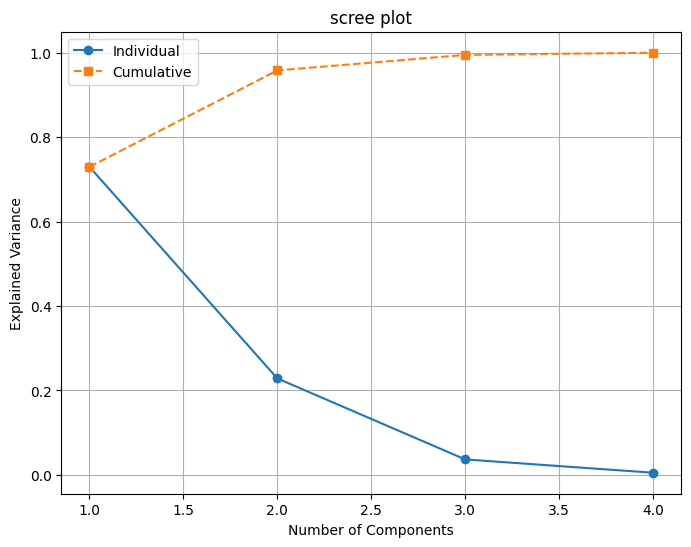

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
pca=PCA()
x_pca=pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.plot(range(1,len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_,'o-',label="Individual")
plt.plot(range(1,len(pca.explained_variance_ratio_)+1),np.cumsum(pca.explained_variance_ratio_),'s--',label="Cumulative")
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('scree plot')
plt.legend()
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
pca_95=PCA(n_components=0.95)
X_reduced=pca_95.fit_transform(X_scaled)
print(f"Reduced Shape:{X_reduced.shape}")

Reduced Shape:(150, 2)


**Visualize Top 2 Components:**

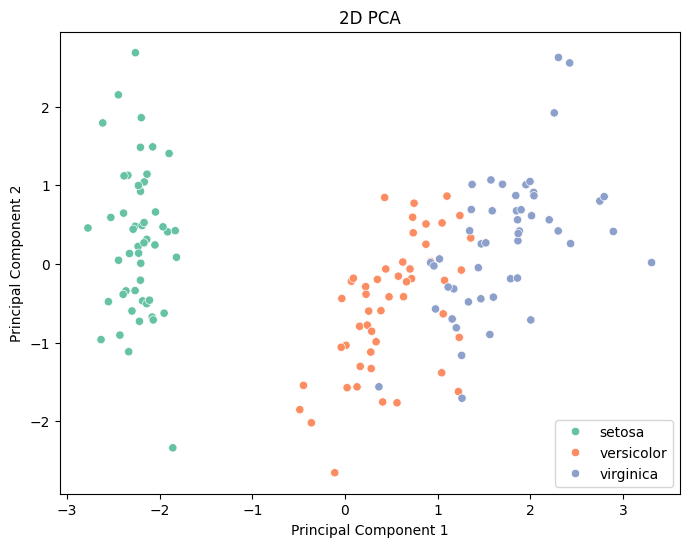

In [ ]:
pca_2d=PCA(n_components=2)
X_2d=pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0],y=X_2d[:,1],hue=iris.target_names[y],palette='Set2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA')
plt.show()

Part 1 – Data Preparation
Load the dataset.

Select only numerical features relevant to customer behavior.


Handle missing values.


Standardize the data.


🔹 Part 2 – PCA Implementation

Apply PCA on the standardized dataset.

Plot the explained variance ratio.

Determine:

How many principal components are needed to retain at least 90% of total variance?

Reduce the dataset to those components.

🔹 Part 3 – Interpretation
Identify:

Which original features contribute most to PC1?

Which features dominate PC2?

Explain what PC1 and PC2 represent in business terms.

🔹 Part 4 – Practical Application

Visualize customers in 2D PCA space.

Now apply K-Means clustering on:

Original dataset

PCA-reduced dataset

Compare:

Silhouette score

Computation time

Cluster separation quality

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/marketing_campaign.csv',sep='\t')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.shape

(2240, 29)

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
df=df[['Income','Kidhome','Teenhome','Recency','MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']]

In [ ]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
# Check missing values
print(df.isnull().sum())

# Replace missing Income with median
df['Income'].fillna(df['Income'].median(), inplace=True)


Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


/tmp/ipython-input-3929215772.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca_data = pca.fit_transform(scaled_data)


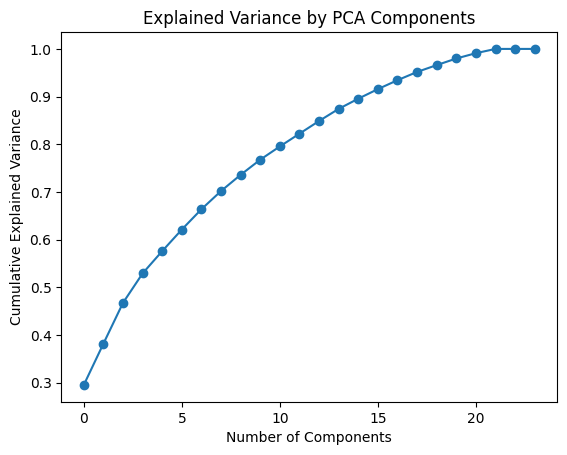

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()


In [ ]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print("Components needed for 90% variance:", n_components_90)


Components needed for 90% variance: 16


In [ ]:
pca_final = PCA(n_components=n_components_90)
reduced_data = pca_final.fit_transform(scaled_data)


In [ ]:
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
                        index=df.columns)

print(loadings[['PC1','PC2']])

                          PC1       PC2
Income               0.290615  0.030167
Kidhome             -0.253955  0.001046
Teenhome            -0.061695  0.400597
Recency              0.000674 -0.040273
MntWines             0.306155  0.259173
MntFruits            0.268366 -0.184135
MntMeatProducts      0.313712 -0.129916
MntFishProducts      0.277907 -0.195892
MntSweetProducts     0.270328 -0.154345
MntGoldProds         0.221566  0.074713
NumDealsPurchases   -0.057008  0.454955
NumWebPurchases      0.209478  0.345110
NumCatalogPurchases  0.318926  0.008174
NumStorePurchases    0.282599  0.130402
NumWebVisitsMonth   -0.248176  0.299521
AcceptedCmp3         0.021180  0.071473
AcceptedCmp4         0.096735  0.340190
AcceptedCmp5         0.194487  0.071247
AcceptedCmp1         0.172814  0.079616
AcceptedCmp2         0.059045  0.238067
Complain            -0.015799 -0.019020
Z_CostContact        0.000000 -0.000000
Z_Revenue            0.000000 -0.000000
Response             0.110207  0.170580


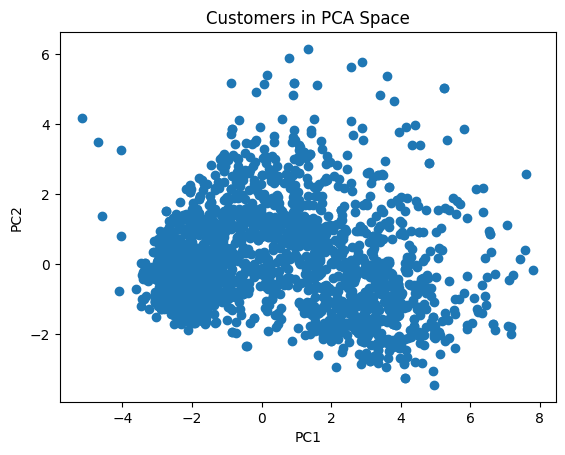

In [ ]:
plt.figure()
plt.scatter(pca_data[:,0], pca_data[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space")
plt.show()


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

start = time.time()
kmeans_original = KMeans(n_clusters=4, random_state=42)
labels_original = kmeans_original.fit_predict(scaled_data)
time_original = time.time() - start

sil_original = silhouette_score(scaled_data, labels_original)

print("Original Silhouette:", sil_original)
print("Original Time:", time_original)


Original Silhouette: 0.21063222653651237
Original Time: 0.1409139633178711


In [ ]:
start = time.time()
kmeans_pca = KMeans(n_clusters=4, random_state=42)
labels_pca = kmeans_pca.fit_predict(reduced_data)
time_pca = time.time() - start

sil_pca = silhouette_score(reduced_data, labels_pca)

print("PCA Silhouette:", sil_pca)
print("PCA Time:", time_pca)


PCA Silhouette: 0.2695887308846591
PCA Time: 0.045610666275024414
